In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv')
df.tail()

,teamId,teamName,matches,avg_xG,total_xG,avg_xG_open_play,avg_xG_set_play,avg_xG_non_penalty,mean_ball_possession,fouls,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
43,287981,Curacao,2,0.455,0.91,0.365,0.09,0.455,30.0,441,...,22,3,33,24,11,57,19,102,5,0
44,6724,Paraguay,2,0.430,0.86,0.210,0.22,0.430,28.5,328,...,23,4,46,19,16,81,8,127,6,1
45,5902,Qatar,2,0.410,0.82,0.350,0.06,0.410,26.5,304,...,9,1,30,21,23,92,9,70,3,2
46,7795,Saudi Arabia,2,0.400,0.80,0.100,0.30,0.400,33.0,530,...,12,3,26,22,8,78,14,77,3,0
47,6719,Tunisia,2,0.165,0.33,0.025,0.14,0.165,44.5,576,...,18,7,39,20,7,36,2,89,1,0


In [7]:
df.columns

Index(['teamId', 'teamName', 'matches', 'avg_xG', 'total_xG',
       'avg_xG_open_play', 'avg_xG_set_play', 'avg_xG_non_penalty',
       'mean_ball_possession', 'fouls', 'accurate_passes',
       'accurate_long_passes', 'accurate_crosses', 'ground_duels_won',
       'aerial_won', 'dribbles_succeeded', 'goals', 'big_chances',
       'big_chances_missed', 'corners', 'total_shots', 'shots_off_target',
       'blocked_shots', 'hit_woodwork', 'shots_inside_box',
       'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [2]:
df[['teamName', 'goals', 'avg_xG', 'total_xG']].sort_values(by='goals', ascending=False).head()

,teamName,goals,avg_xG,total_xG
1,Germany,9,3.025,6.05
2,Canada,7,2.925,5.85
4,Norway,7,2.360,4.72
11,Netherlands,7,1.695,3.39
5,France,6,2.280,4.56


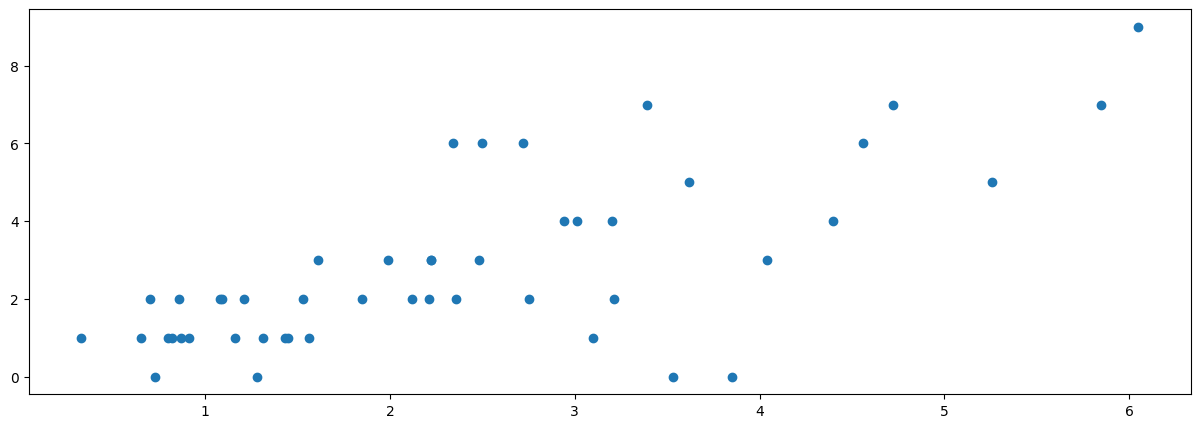

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.scatter(x=df.total_xG, y=df.goals)

In [37]:
df.columns

Index(['teamId', 'teamName', 'matches', 'avg_xG', 'total_xG',
       'avg_xG_open_play', 'avg_xG_set_play', 'avg_xG_non_penalty',
       'mean_ball_possession', 'fouls', 'accurate_passes',
       'accurate_long_passes', 'accurate_crosses', 'ground_duels_won',
       'aerial_won', 'dribbles_succeeded', 'goals', 'big_chances',
       'big_chances_missed', 'corners', 'total_shots', 'shots_off_target',
       'blocked_shots', 'hit_woodwork', 'shots_inside_box',
       'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [115]:
# top 10 avg teams for viz
ten_avg_xG = df[['teamName', 'total_xG', 'goals']].sort_values(by='total_xG', ascending=False).head(10)
ten_avg_xG

,teamName,total_xG,goals
1,Germany,6.05,9
2,Canada,5.85,7
3,Switzerland,5.26,5
4,Norway,4.72,7
5,France,4.56,6
6,Spain,4.40,4
7,Uruguay,4.04,3
8,Ecuador,3.85,0
9,Argentina,3.62,5
10,Turkiye,3.53,0


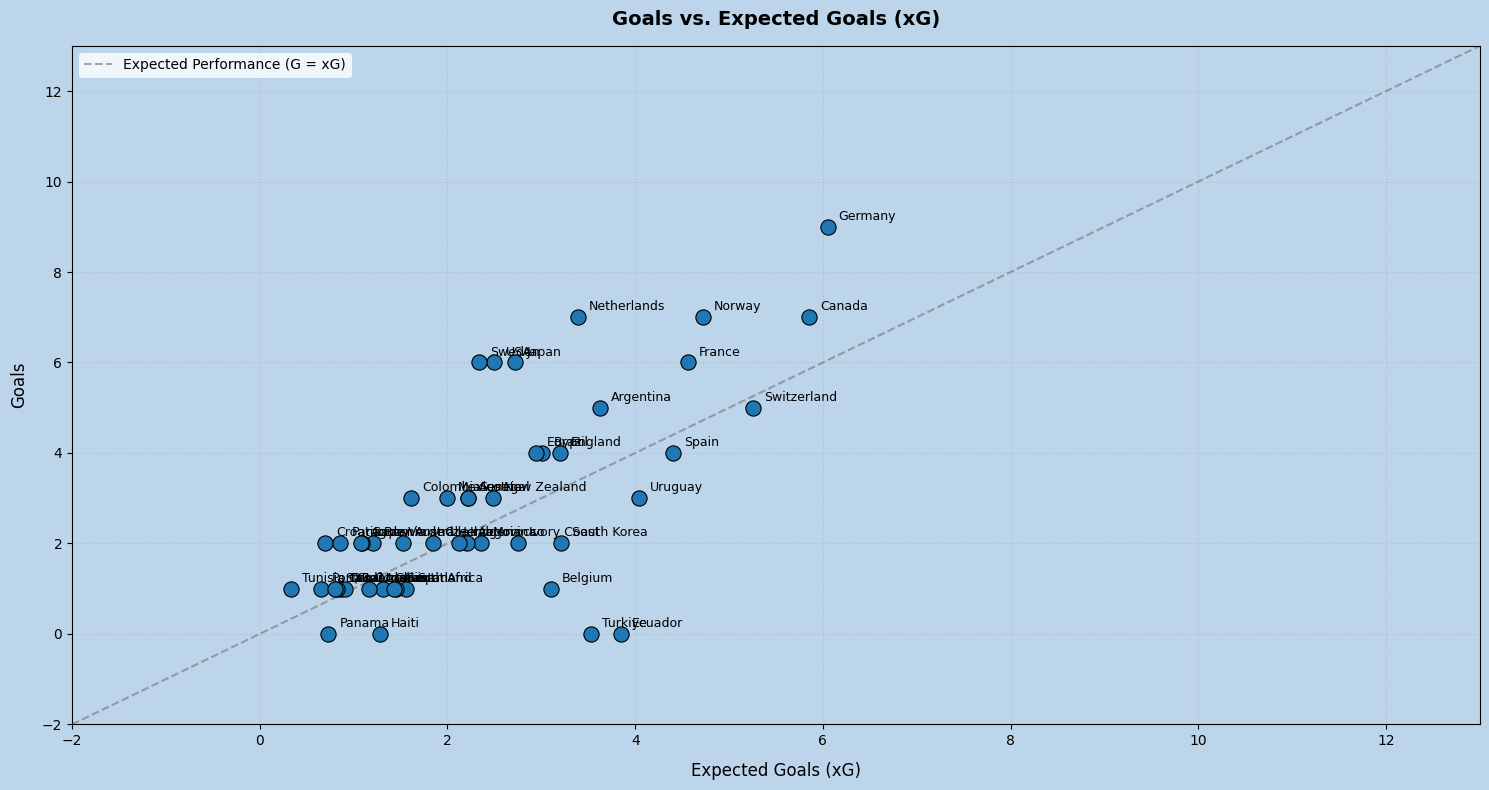

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the plot
plt.figure(figsize=(15, 8), dpi=100, facecolor="#BDD5EA")

ax = plt.gca()
ax.set_facecolor("#BDD5EA") 

# 2. Dynamic axis limit calculation to keep the chart perfectly square, it compares the two values and returns the max/min of the two
max_val = max(max(df.goals), max(df.total_xG)) + 4
min_val = min(min(df.goals), min(df.total_xG)) - 2

# 3. Draw a line on the chart(Where Goals == xG)
plt.plot(
    [min_val, max_val],
    [min_val, max_val], 
    color='gray', 
    linestyle='--', 
    alpha=0.7, 
    linewidth=1.5,
    label='Expected Performance (G = xG)'
)

# 4. Plot the team data points
plt.scatter(
    df.total_xG,
    df.goals,
    color='#1f77b4', 
    s=120, 
    edgecolors='black', 
    linewidths=0.8, 
    zorder=5
)

# 5. Annotate each data point with the team's name
for i, name in enumerate(df.teamName):
    plt.annotate(
        name, 
        (df.total_xG[i], df.goals[i]), 
        xytext=(8, 5), # Offsets the text slightly up and right
        textcoords='offset points', 
        fontsize=9,
        fontweight='medium'
    )

# 7. Labels, Title, and Formatting
plt.xlabel('Expected Goals (xG)', fontsize=12, labelpad=10)
plt.ylabel('Goals', fontsize=12, labelpad=10)
plt.title('Goals vs. Expected Goals (xG)', fontsize=14, fontweight='bold', pad=15)

# Ensure the plot is a perfect square visually to maintain line geometry
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca()
# plt.gca().set_aspect('equal', adjustable='box')

# Add subtle layout helpers
plt.grid(True, linestyle=':', alpha=0.6, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 8. Render the visualization
plt.tight_layout()

# save imgC:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv
# plt.savefig(r'C:\Users\Public\Documents\Axel\images\xG_Goals.png', dpi=300, bbox_inches='tight', pad_inches=0.35)

plt.show()

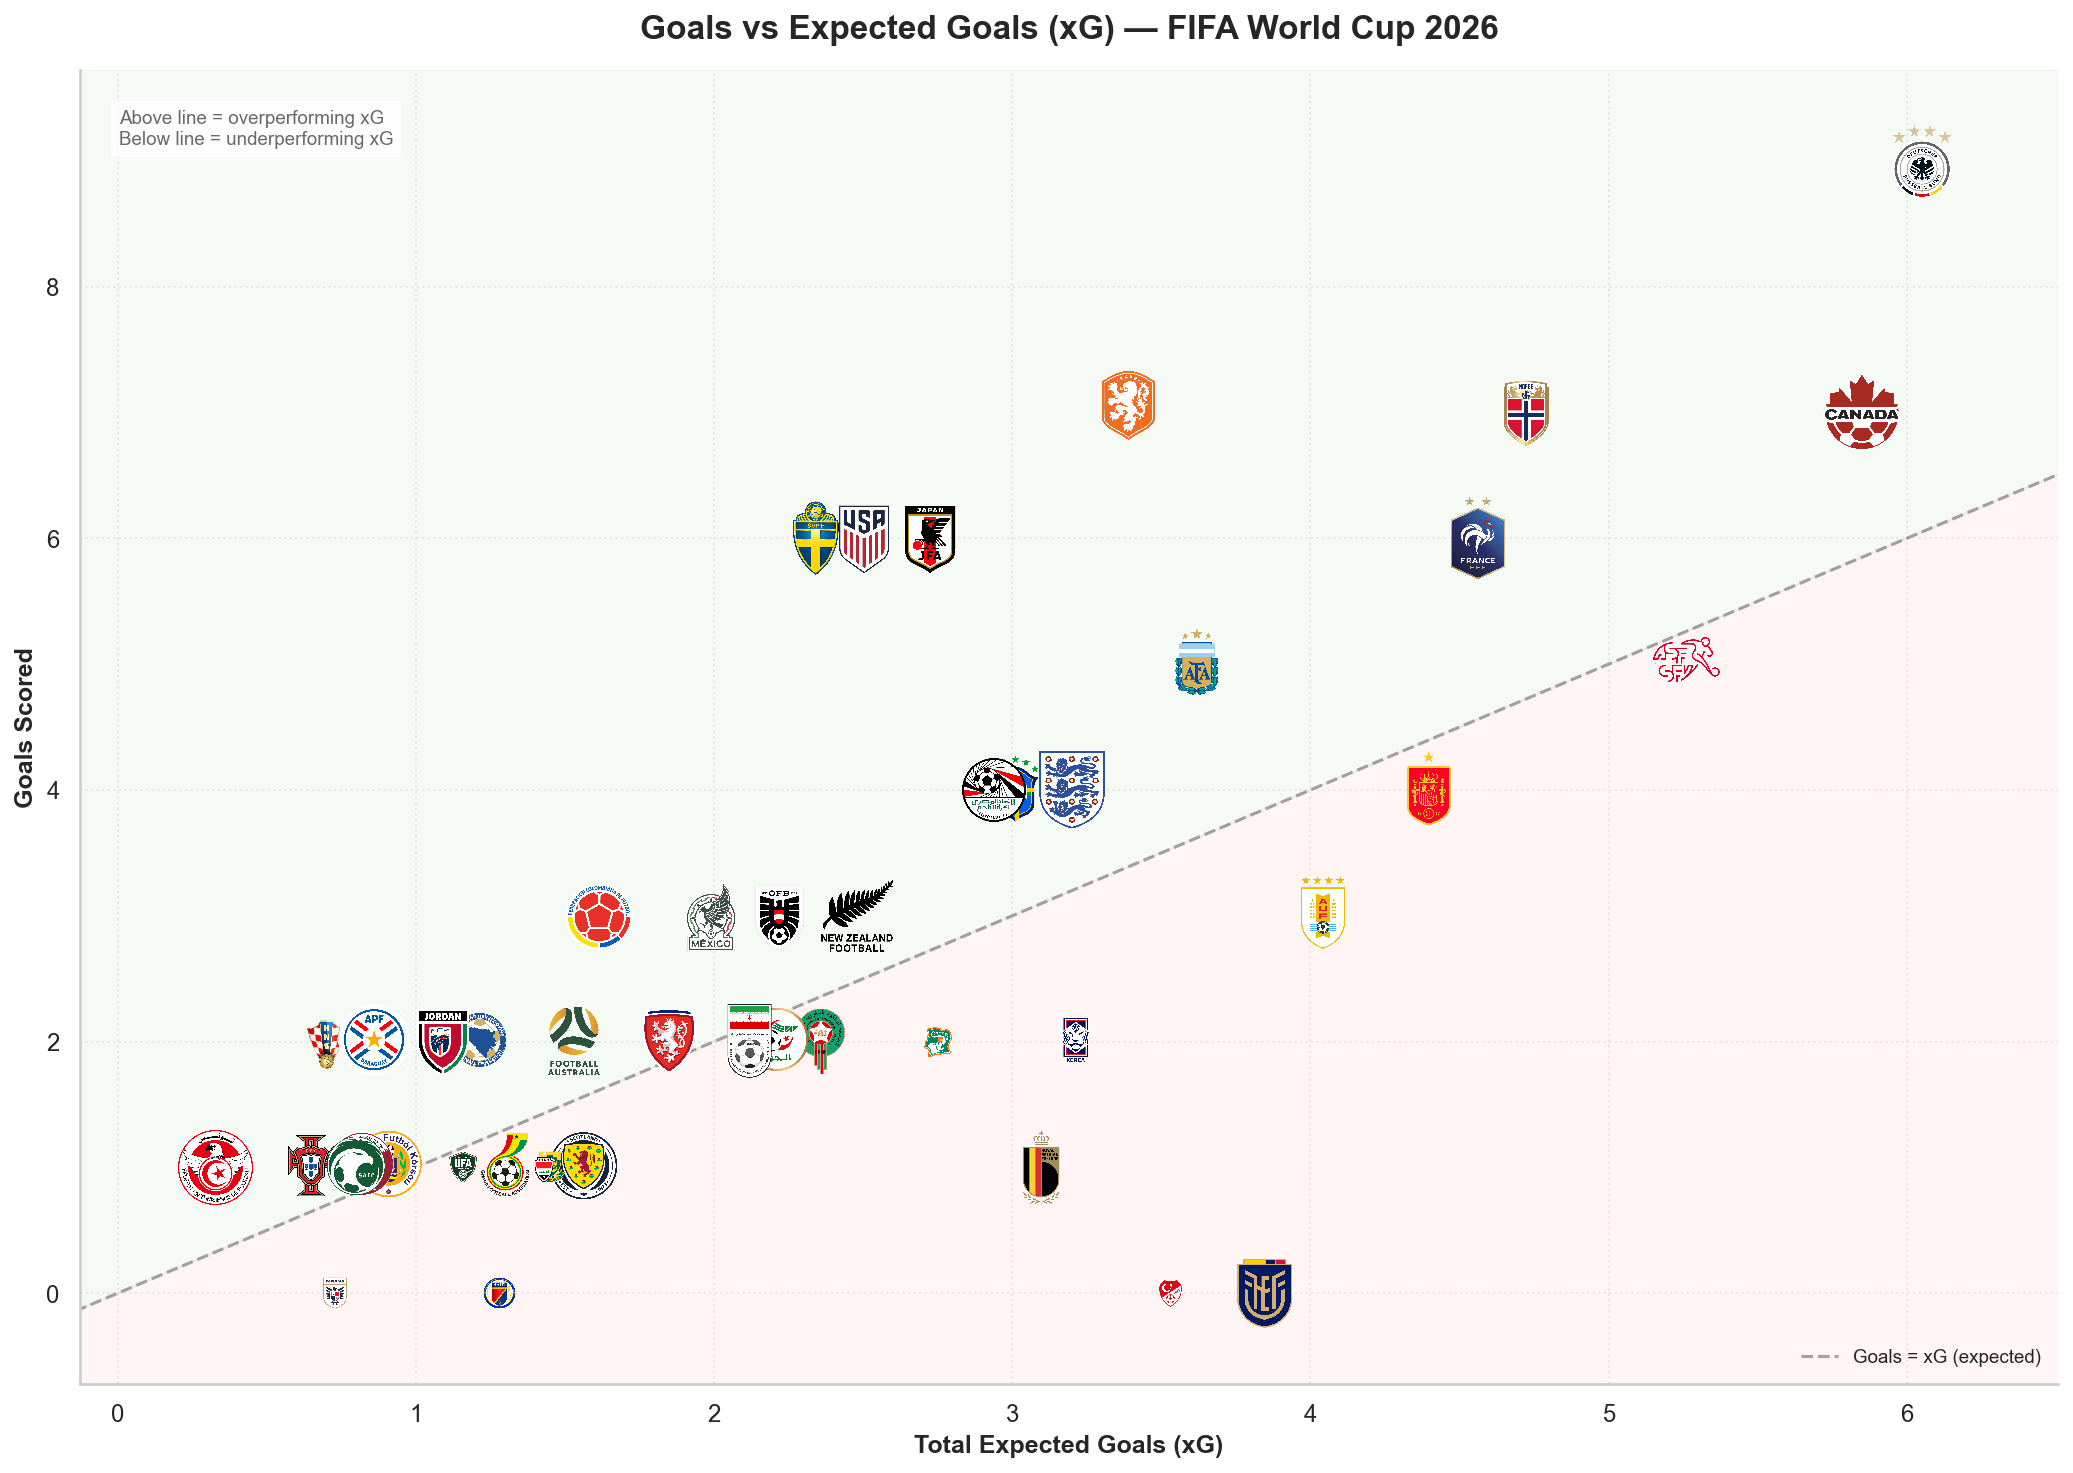

In [48]:
# Claude Matplotlib with team logos https://claude.ai/chat/50421c8d-d5ca-4a39-b6ec-0df23783800f

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import numpy as np

# --- Config ---
logo_folder = logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"  # folder where team logos live
logo_zoom = 0.03        # adjust based on your image resolution
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

# --- Compute axis limits with padding so logos don't get clipped ---
x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y

# --- Diagonal reference line (goals == xG) ---
lims = [min(x_min, y_min), max(x_max, y_max)]
ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1.5, alpha=0.7, zorder=1, label='Goals = xG (expected)')

# --- Plot each team's logo at (total_xG, goals) ---
def get_logo(team_id, zoom=logo_zoom):
    path = os.path.join(logo_folder, f"{team_id}.png")
    img = mpimg.imread(path)
    return OffsetImage(img, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(
            get_logo(row['teamId']),
            (row['total_xG'], row['goals']),
            frameon=False,
            zorder=3
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        # fallback: plot a labeled dot if logo missing
        ax.scatter(row['total_xG'], row['goals'], color='green', s=20, zorder=3)
        ax.annotate(row['teamName'], (row['total_xG'], row['goals']), fontsize=6)

# --- Shaded regions to show over/under performance ---
ax.fill_between(lims, lims, y_max, color='green', alpha=0.04, zorder=0)  # overperforming (goals > xG)
ax.fill_between(lims, y_min, lims, color='red', alpha=0.04, zorder=0)    # underperforming

# --- Labels, title, styling ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals Scored', fontsize=12, fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
ax.text(0.02, 0.97, 'Above line = overperforming xG\nBelow line = underperforming xG',
        transform=ax.transAxes, fontsize=9, va='top', color='dimgray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
# plt.savefig('goals_vs_xg_worldcup2026.png', dpi=300, bbox_inches='tight')
plt.show()

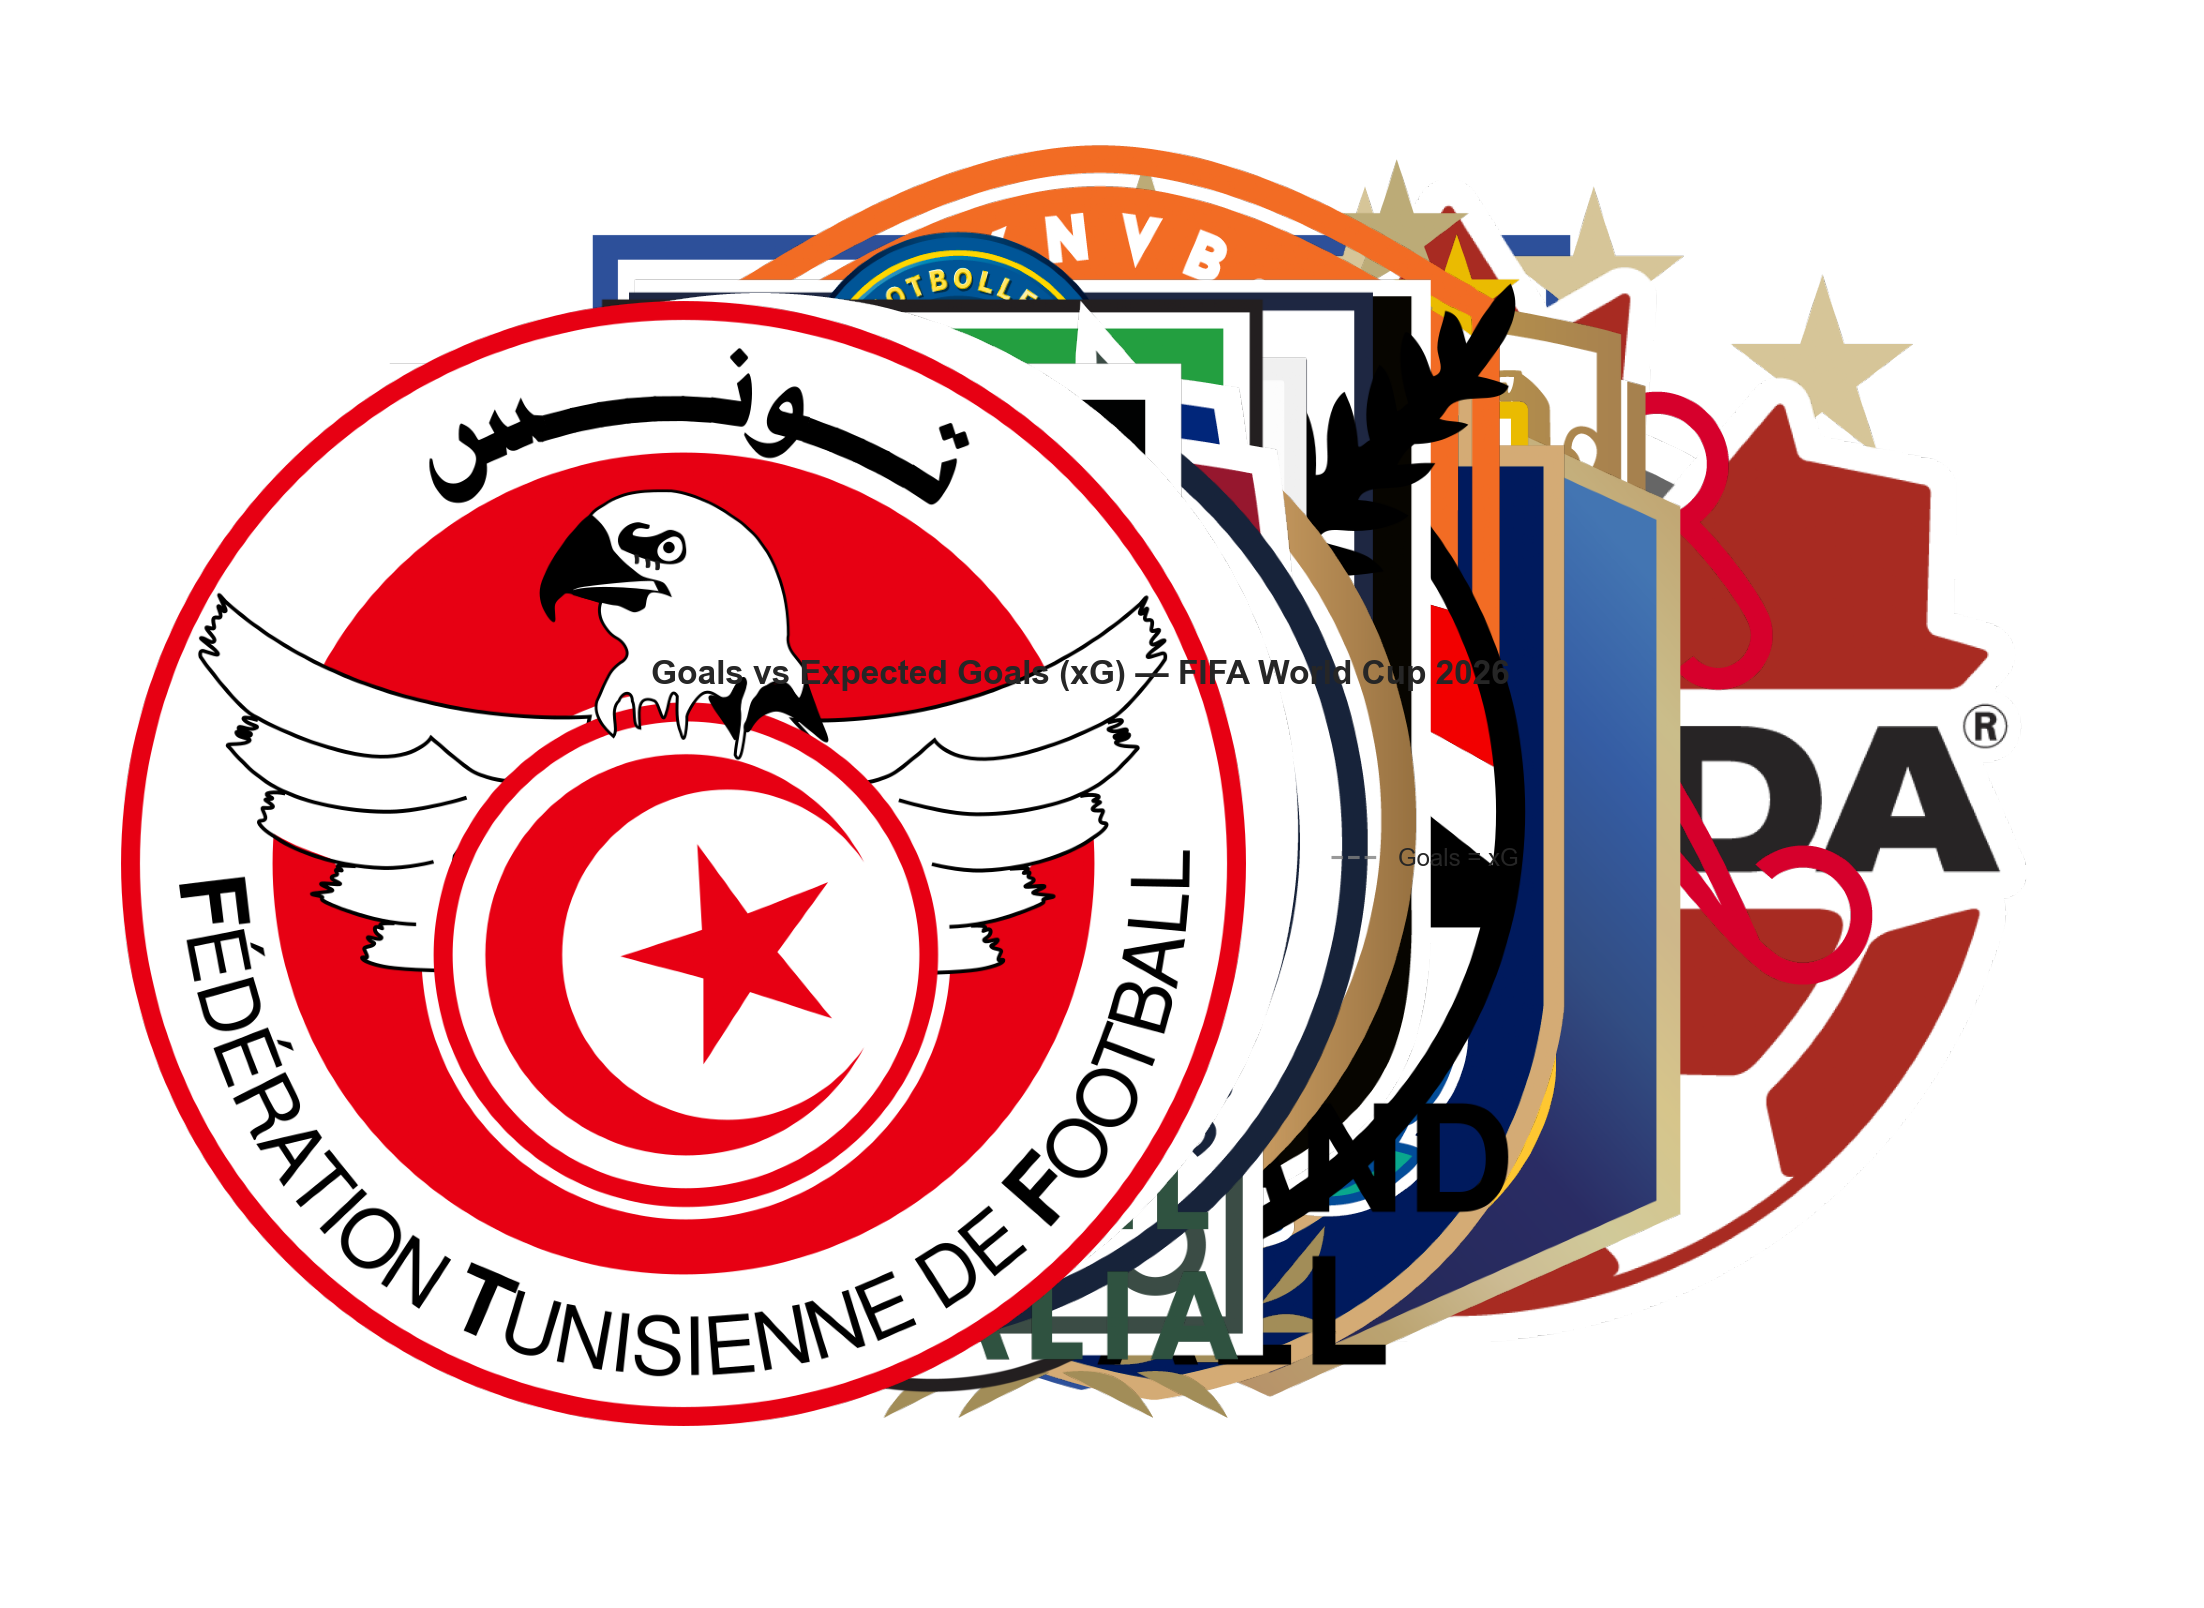

In [46]:
# Claude Seabon with team logos https://claude.ai/chat/50421c8d-d5ca-4a39-b6ec-0df23783800f

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

sns.set_theme(style="whitegrid", font_scale=1.05)

logo_folder = r"C:\Users\Public\Documents\Axel\team_logos"
logo_zoom = 0.45

fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

x = df['total_xG']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y
lims = [min(x_min, y_min), max(x_max, y_max)]

# Invisible scatter just so seaborn sets up a nice themed axis/grid first
sns.scatterplot(data=df, x='total_xG', y='goals', alpha=0, ax=ax)

ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1.5, alpha=0.8, zorder=1, label='Goals = xG')

def get_logo(team_id, zoom=logo_zoom):
    path = os.path.join(logo_folder, f"{team_id}.png")
    img = mpimg.imread(path)
    return OffsetImage(img, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(get_logo(row['teamId']), (row['total_xG'], row['goals']),
                             frameon=False, zorder=3)
        ax.add_artist(ab)
    except FileNotFoundError:
        sns.scatterplot(x=[row['total_xG']], y=[row['goals']], color='red', s=30, ax=ax, zorder=3)

ax.fill_between(lims, lims, y_max, color='seagreen', alpha=0.05, zorder=0)
ax.fill_between(lims, y_min, lims, color='firebrick', alpha=0.05, zorder=0)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Expected Goals (xG)', fontweight='bold')
ax.set_ylabel('Goals Scored', fontweight='bold')
ax.set_title('Goals vs Expected Goals (xG) — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
sns.despine()
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
# plt.savefig('goals_vs_xg_worldcup2026_seaborn.png', dpi=300, bbox_inches='tight')
plt.show()

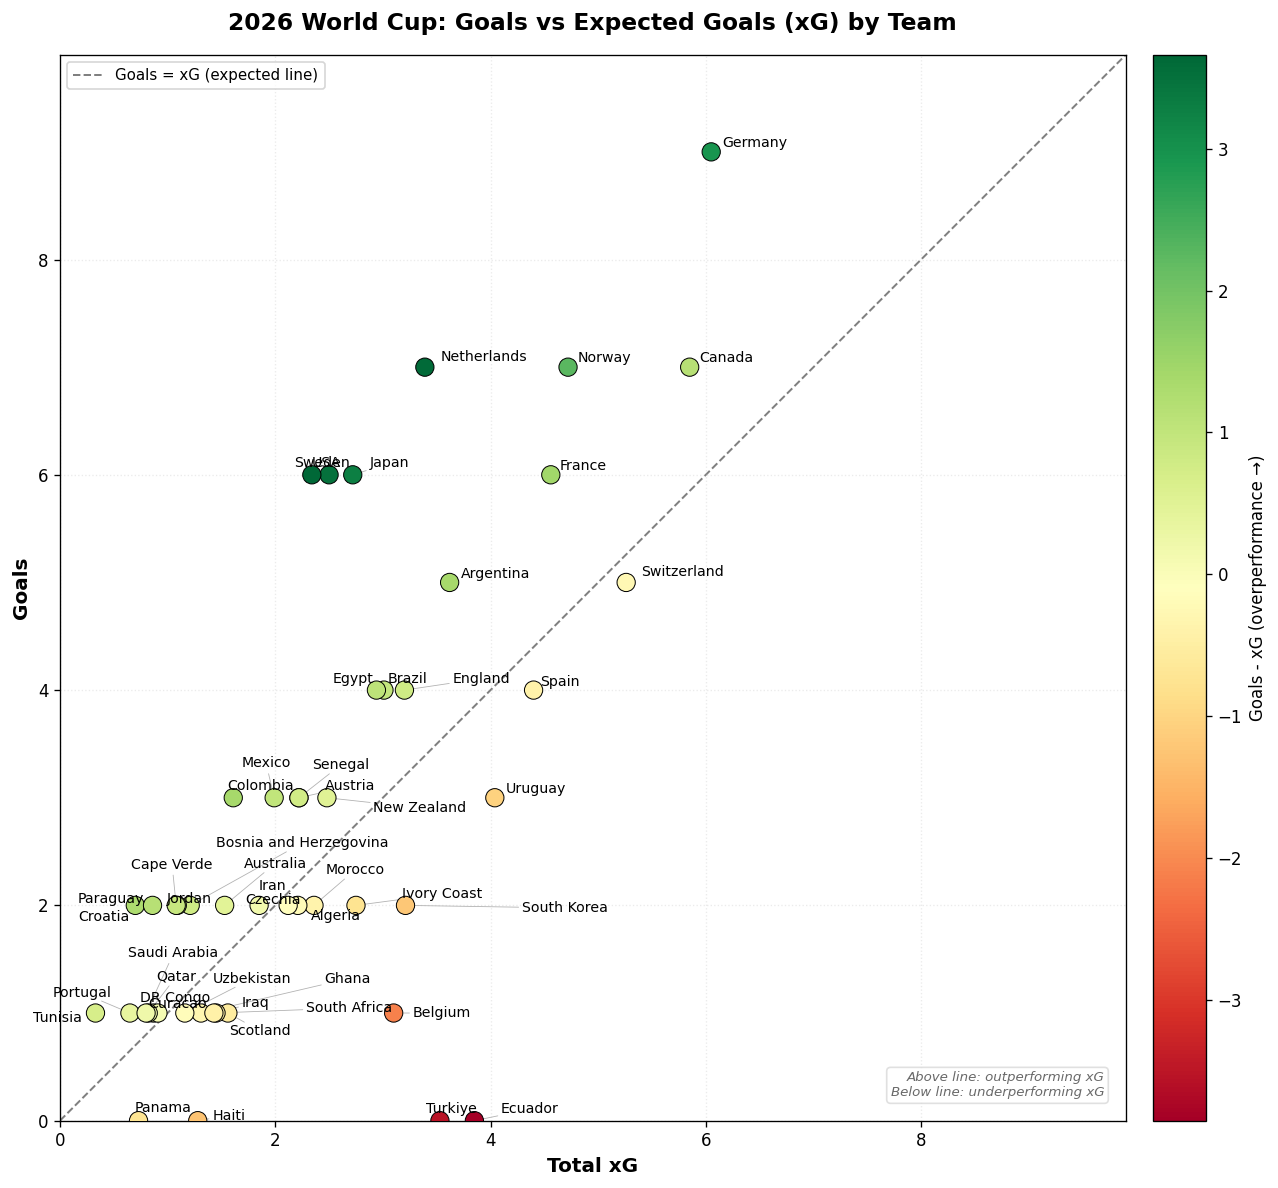

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

# Compute over/underperformance for coloring
df['xG_diff'] = df['goals'] - df['total_xG']

# Diagonal reference line (y = x) — defines "performed as expected"
max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
min_val = 0
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG (expected line)')

# Scatter, colored by over/underperformance
scatter = ax.scatter(
    df['total_xG'], df['goals'],
    c=df['xG_diff'], cmap='RdYlGn', s=120,
    edgecolors='black', linewidth=0.6, zorder=3
)

# Colorbar to explain the color coding
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Goals - xG (overperformance →)', fontsize=10)

# Team name labels, auto-adjusted to avoid overlap
texts = []
for _, row in df.iterrows():
    texts.append(
        ax.text(row['total_xG'], row['goals'], row['teamName'],
                fontsize=8.5, zorder=4)
    )
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG) by Team',
             fontsize=14, fontweight='bold', pad=15)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25, linestyle=':')
ax.legend(loc='upper left', fontsize=9, frameon=True)

# Subtle annotation explaining the diagonal
ax.text(0.98, 0.02, 'Above line: outperforming xG\nBelow line: underperforming xG',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        style='italic', color='dimgray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='lightgray'))

plt.tight_layout()
plt.savefig('goals_vs_xg_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

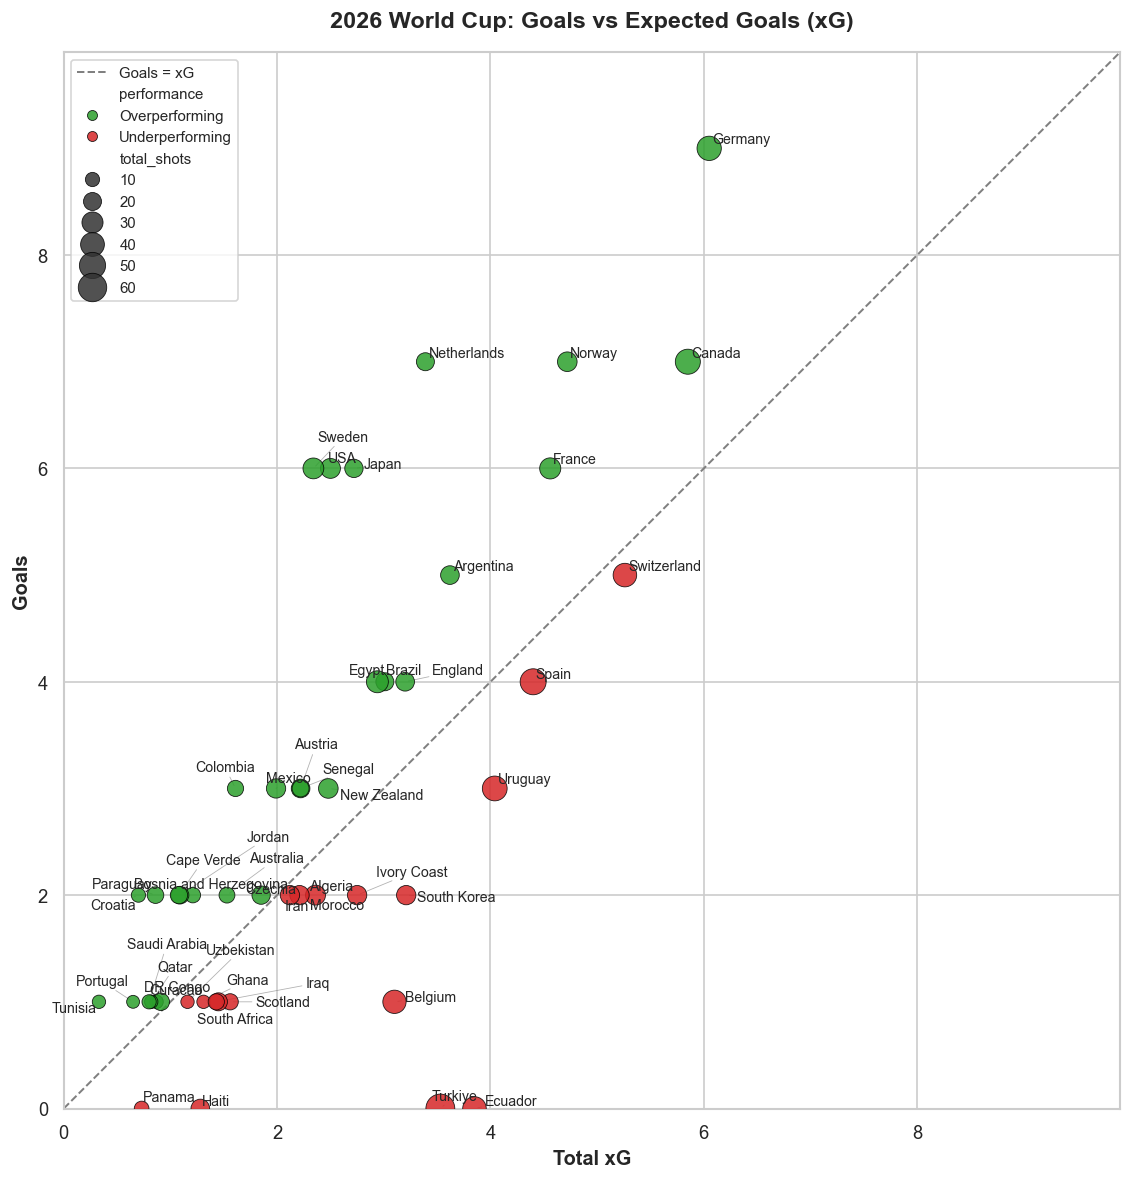

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

sns.set_theme(style='whitegrid', font_scale=1.0)

df['xG_diff'] = df['goals'] - df['total_xG']
df['performance'] = np.where(df['xG_diff'] >= 0, 'Overperforming', 'Underperforming')

fig, ax = plt.subplots(figsize=(12, 10), dpi=120)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1

# Diagonal reference line
ax.plot([0, max_val], [0, max_val],
        linestyle='--', color='gray', linewidth=1.2, zorder=1,
        label='Goals = xG')

# Seaborn scatterplot, sized by total_shots if you want an extra dimension
sns.scatterplot(
    data=df, x='total_xG', y='goals',
    hue='performance', palette={'Overperforming': '#2ca02c', 'Underperforming': '#d62728'},
    size='total_shots', sizes=(60, 300), alpha=0.85,
    edgecolor='black', linewidth=0.5, ax=ax, zorder=3
)

# Labels with adjustText to dodge overlaps
texts = [
    ax.text(row['total_xG'], row['goals'], row['teamName'], fontsize=8.5, zorder=4)
    for _, row in df.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6))

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Total xG', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals', fontsize=12, fontweight='bold')
ax.set_title('2026 World Cup: Goals vs Expected Goals (xG)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(title='', loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('goals_vs_xg_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import plotly.express as px

df['xG_diff'] = df['goals'] - df['total_xG']

fig = px.scatter(
    df, x='total_xG', y='goals', text='teamName',
    color='xG_diff', color_continuous_scale='RdYlGn',
    hover_data=['matches', 'total_shots', 'big_chances'],
    title='2026 World Cup: Goals vs xG'
)

max_val = max(df['goals'].max(), df['total_xG'].max()) * 1.1
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(dash='dash', color='gray'))

fig.update_traces(textposition='top center', textfont_size=8, marker=dict(size=10))
fig.update_layout(xaxis_range=[0, max_val], yaxis_range=[0, max_val], width=900, height=900)
fig.show()